# EXERCISE 08: Optimization problems

## 08.1

<b> Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian <b>
 $$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$
In which:
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$
$$
V(x) = x^4 - \frac{5}{2}x^2
$$

The expectation value of the hamiltonian can be computed using an importance sampling technique, meaning that we use extract points from the trial wavefunction instead of a uniform distribution to be able to reach an accurate value of the integral faster and in a more precise way. In this first points I used some trial values of mu and sigma that I deduced from the theoretical model that is plotted in the exercise question, which are: $\mu = 0.85$, $\sigma = 0.65$ ( initially I tried sigma = 0.5 and mu = 0.8 and I adjusted it until the histogram approached the theoretical line in a correct way)

#### Metropolis sampling of the wavefunction
In order to do this  I created a modified version of the Metropolis algorithm, that takes 1D steps with an input step length that is chosen so that the acceptance rate approaches 50%, and accceptsmoves with the usual Metropolis acceptance rate(same function I used in exercise 5).
``` c++
void Metropolis_Step(Random& rnd, double &position,double step_length,double &acc_rate, double mu, double sigma){
	
	double old_pos = position;

	double new_pos=old_pos+step_length*rnd.Rannyu(-1,1);
	double p_old = mu,sigma,old_pos;
	double p_new = psi_T(mu,sigma,new_pos);
	double T_bkw=1.;
	double T_fwd =1.;

	double A=Metropolis_Acceptance(p_new,p_old,T_fwd,T_bkw);
	
	double x = rnd.Rannyu();
	if (x<A){
		acc_rate++;
		position = new_pos;
}
else position = old_pos;
}

I first performed an equilibration of the system to let the acceptance rate stabilize to 50%, and in the fllowing plot we can see that 2000 steps with steplength 2.75 are sufficient to reach the desired result. To compare the point distribution with the trial wavefunction I initially executed the simulation with only 1 block of 100000 steps, that resulted in the histogram below:

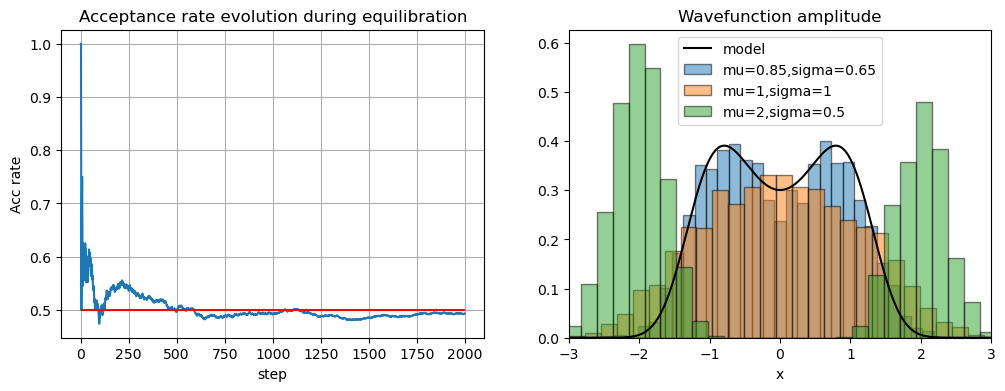

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

fig,ax = plt.subplots(1,2,figsize=(12,4))

#equilibration
df_acc=pd.read_csv("./OUTPUT/acceptance.csv",sep='\t')
ax[0].plot(df_acc['step'],df_acc['acc_rate'])
ax[0].hlines(0.5,0,2000,color='r')
ax[0].set_title("Acceptance rate evolution during equilibration")
ax[0].set_xlabel("step")
ax[0].set_ylabel ("Acc rate")
ax[0].grid()

#MODEL
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2
hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

#DATA
df= pd.read_csv('./OUTPUT/psi_sampling_correct.csv',sep='\t')
df1= pd.read_csv('./OUTPUT/psi_sampling_ones.csv',sep='\t')
df2= pd.read_csv('./OUTPUT/psi_sampling_peaks.csv',sep='\t')

#plot
ax[1].plot(x,(psi[0])**2,color='black',label='model')
ax[1].hist(df['x'],bins=30,alpha=0.5,edgecolor='black',density=True,label ='mu=0.85,sigma=0.65')
ax[1].hist(df1['x'],bins=30,alpha=0.5,edgecolor='black',density=True,label ='mu=1,sigma=1')
ax[1].hist(df2['x'],bins=30,alpha=0.5,edgecolor='black',density=True,label ='mu=2,sigma=0.5')
ax[1].set_title("Wavefunction amplitude")
ax[1].set_xlabel("x")
ax[1].set_xlim((-3,3))
ax[1].legend()


plt.show()

#### Evaluation of $\langle H \rangle$
To evaluate the integral, I used the importance samplng method: first I used the Metropolis I algorithm I showed before to sample a point in the normalized distribution $|\psi |^2$, then I evaluated $\hat{H} \psi$ in that point and incremented the sum variable that keeps track of the integral value. I did this for $10^5$ steps and obtained the final value of the integral, and then repeated for 50 blocks to obtain the final block averaged value.
``` c++

	for (int i=1; i<Nsteps; i++){ //steps of RW
		double old_pos = position;
		out<<i<<"\t"<<position<<endl;
		Metropolis_Step(rnd,position,step_length,acc_rate,mu,sigma);
		integral+= Hpsi(mu,sigma,position)/psi_T(mu,sigma,position);	
	}
	
	double ave = integral/double(Nsteps);
	block_ave += ave;
	block_ave2 += ave*ave;
	double err = sqrt((block_ave2/double(j+1)-pow(block_ave/double(j+1),2))/double(j+1));

	outr<<j<<"\t"<<integral/double(Nsteps)<<"\t"<<block_ave/double(j+1)<<"\t"<<err<<endl;

}

Measured Ground state energy: 5216.49


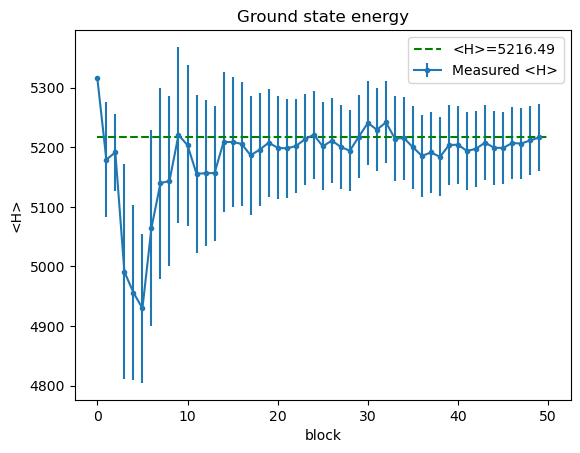

In [2]:
import matplotlib.pyplot as plt 
import pandas as pd 

df=pd.read_csv('./OUTPUT/ave_prova.csv',sep ='\t')
GS = -0.44
plt.errorbar(df['block'],df['prog_ave'],yerr=df['err'],marker ='.',label='Measured <H>')
#plt.hlines(GS,0,50,color='red',linestyle ='dashed',label=f'Model <H>={GS}')
plt.hlines(df['prog_ave'][49],0,50,color ='green',linestyle='dashed',label=f'<H>={df['prog_ave'][49]}')
plt.title('Ground state energy')
plt.xlabel('block')
plt.ylabel('<H>')
plt.legend()

print(f'Measured Ground state energy: {df['prog_ave'][49]}')

## 08.2

<b>To find the parameters $\sigma$ and $\mu$ which minimize $\langle {\hat H} \rangle_T$, extend your Variational Monte Carlo code to face the variational optimization problem via a <span style="color:red">Simulated Annealing (SA) algorithm</span>. <b>

The SA algorithm I used has the following basic structure:
- outer *for* cycle that lowers the temperature incrementing beta: ``` beta *=1.2```. I chose this incrementing system to obtain a slow cooling. At the end of every step the value of $\langle H \rangle$, $\mu$ and $\sigma$ are saved. 
- at every fixed beta value I insert two for cycles that perform the block average: the outer one is where the block_ave and error values are updated, the inner one is where the Metropolis step of the simulation takes place.
- at every step at fixed T a new value for mu and sigma is extracted from a gaussian probability distribution centered around the previous values with a width that scales with the temperature (so that when T is lower, and we are closer to the minimum , the steps will be smaller).Then the new value of $\langle H \rangle$ is computed with these proposed values, using the same algorithm I showed in 8.1.
- Lastly, if the new value of $\langle H \rangle$ is lower than the previous one, the move is automatically accepted, if not, the acceptance probability is computed using the Boltzmann weight. In this way, when beta is small, the Boltzmann weight will be higher and the probability of accepting "wrong" moves will also be, allowing the simulation to span a larger portion of the parameter space at large T and slowly approach the correct value as the system cools.

Il modo di incrementare l'errore è efficiente a beta basso, perchè permette di non abbassare troppo velocemente la temperatura, ma invece a beta alto sale troppo veloce e scazza: o lo cambio con una legge lineare, ma perdo di slow cooling, o lascio così e non faccio salire troppo beta

At the end of each block at fixed temperature I save the best value of <H> obtained in that block, and the average of all estimates in that block, to get a more precise idea of what portion of parameter space I am mapping, and estimate the standard deviation, even though this is affected by autocorrelation between the steps. The most ideal way to do this would be either to save the output of every step or apply data blocking inside the T blocks, but it would become too computationally heavy and not strictly necessary to the optimization, since what counts is more the evolution of sigma and mu. I also save the last value obtained in each block to get an "instant" picture of the evolution, which will fluctuate a lot.

/tmp/ipykernel_16981/46221134.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,1].legend()
/tmp/ipykernel_16981/46221134.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,1].legend()


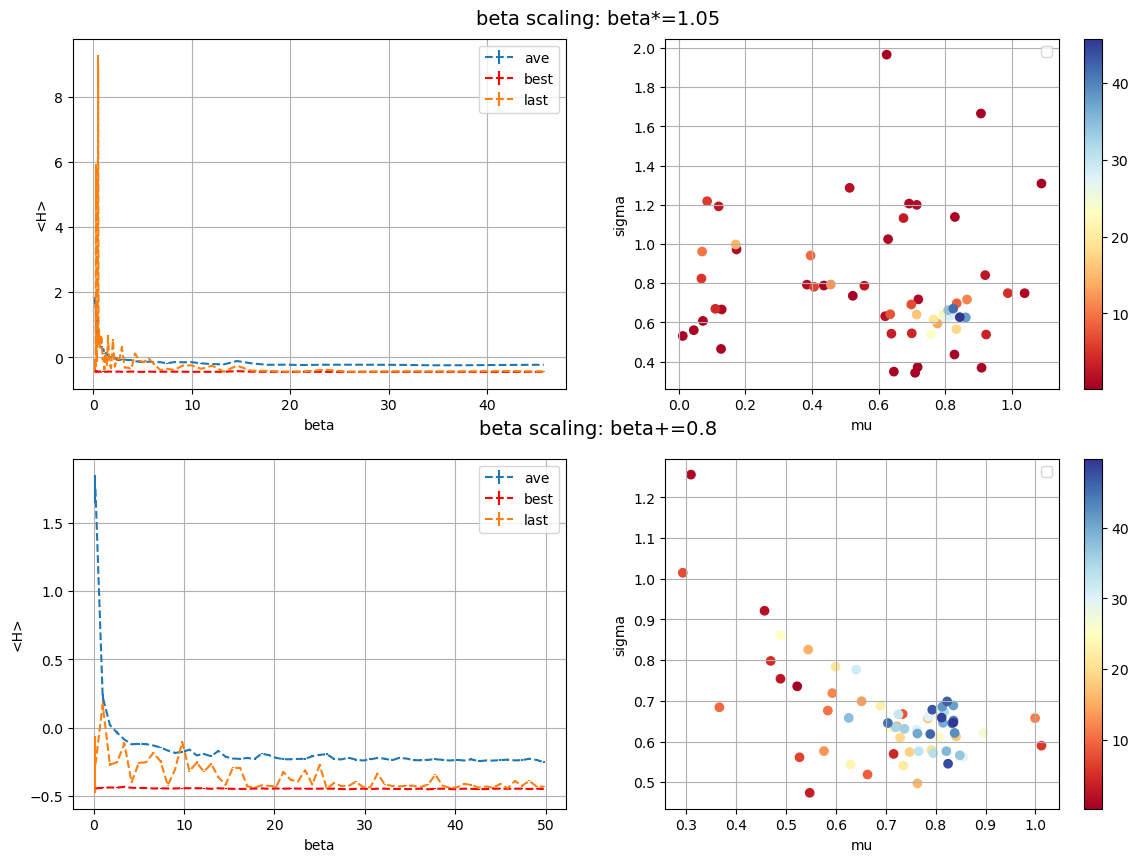

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('./OUTPUT/SAenergy.csv',sep = '\t')
df1 = pd.read_csv ('./OUTPUT/SApars.csv',sep = '\t')

dflin=pd.read_csv('./OUTPUT/SAenergy_lin.csv',sep = '\t')
df1lin = pd.read_csv ('./OUTPUT/SApars_lin.csv',sep = '\t')

fig,ax = plt.subplots(2,2,figsize=(14,10))
fig.text(0.5, 0.9, "beta scaling: beta*=1.05", ha='center', va='center', fontsize=14)
ax[0,0].errorbar(df['beta'],df['meanH_ave'],yerr = df['std_dev'],linestyle = 'dashed',label='ave' )
ax[0,0].errorbar(df['beta'],df['meanH_best'],yerr = df['best_err'],linestyle = 'dashed',label='best',color ='r' )
ax[0,0].errorbar(df['beta'],df['meanH_last'],yerr = df['last_err'],linestyle = 'dashed',label='last' )
#ax[0].hlines (-0.44,df['beta'][0],df['beta'][1],color = 'r',label='<H>=-0.44')
ax[0,0].set_xlabel('beta')
ax[0,0].set_ylabel('<H>')
ax[0,0].grid()
ax[0,0].legend()

sc = ax[0,1].scatter(df1['mu'],df1['sigma'],c=df1['beta'],cmap= 'RdYlBu')
ax[0,1].set_xlabel('mu')
ax[0,1].set_ylabel('sigma')
ax[0,1].legend()
ax[0,1].grid()
cbar = fig.colorbar(sc, ax=ax[0,1])

fig.text(0.5, 0.49, "beta scaling: beta+=0.8", ha='center', va='center', fontsize=14)
ax[1,0].errorbar(dflin['beta'],dflin['meanH_ave'],yerr = dflin['std_dev'],linestyle = 'dashed',label='ave' )
ax[1,0].errorbar(dflin['beta'],dflin['meanH_best'],yerr = dflin['best_err'],linestyle = 'dashed',label='best',color='r' )
ax[1,0].errorbar(dflin['beta'],dflin['meanH_last'],yerr = dflin['last_err'],linestyle = 'dashed',label='last' )
ax[1,0].set_xlabel('beta')
ax[1,0].set_ylabel('<H>')
ax[1,0].legend()
ax[1,0].grid()

sc = ax[1,1].scatter(df1lin['mu'],df1lin['sigma'],c=df1lin['beta'],cmap= 'RdYlBu')
ax[1,1].set_xlabel('mu')
ax[1,1].set_ylabel('sigma')
ax[1,1].legend()
ax[1,1].grid()
cbar = fig.colorbar(sc, ax=ax[1,1])


we can see that the result is achieved faster with a non linear beta scaling

In [23]:
print (f'Best parameters(non linear scaling):\n mu: {df1['mu'][len(df1)-1]} \n sigma: {df1['sigma'][len(df1)-1]}')
print (f'Best parameters(linear scaling):\n mu: {df1lin['mu'][len(df1lin)-1]} \n sigma: {df1lin['sigma'][len(df1lin)-1]}')

Best parameters(non linear scaling):
 mu: 0.843709 
 sigma: 0.626567
Best parameters(linear scaling):
 mu: 0.835487 
 sigma: 0.646959


Using the best estimate of the parameter I can see what is the optimal number of blocks to evaluate H

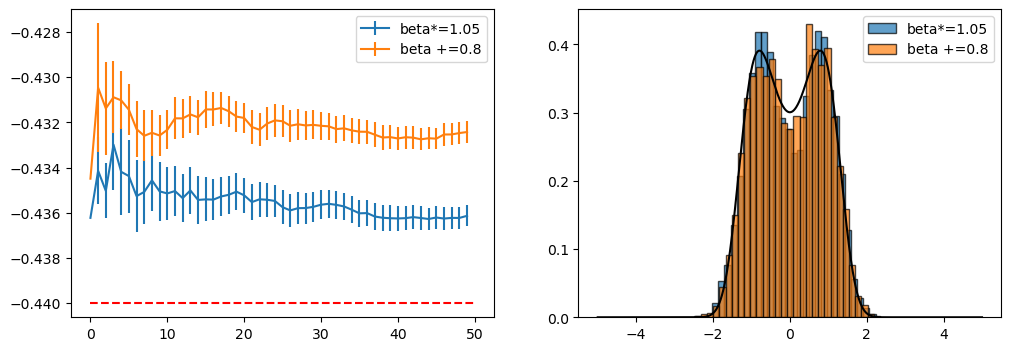

In [28]:
import numpy as np
df = pd.read_csv("./OUTPUT/final_guess_ave.csv",sep = '\t')
df1= pd.read_csv("./OUTPUT/final_sampling.csv",sep = '\t')

dflin = pd.read_csv("./OUTPUT/final_guess_ave_lin.csv",sep = '\t')
df1_lin= pd.read_csv("./OUTPUT/final_sampling_lin.csv",sep = '\t')

fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].errorbar(df['block'],df['prog_ave'],yerr=df['err'],label='beta*=1.05')
ax[0].errorbar(dflin['block'],dflin['prog_ave'],yerr=dflin['err'],label='beta +=0.8')
ax[0].hlines (-0.44,0,50,color='r',linestyle = 'dashed') 
ax[0].legend()
ax[1].hist(df1['x'],bins=30,alpha =0.7, edgecolor='black',density = True,label='beta*=1.05')
ax[1].hist(df1_lin['x'],bins=30,alpha =0.7, edgecolor='black',density = True,label='beta +=0.8')
ax[1].legend()



#MODEL
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2
hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)
ax[1].plot(x,(psi[0])**2,color='black',label='model')